# Wildfire Physical Risk Pipeline — Output Visualization

Temporary notebook for exploring pipeline outputs. Run cells in order.
All paths are relative to the project root (`~/wildfire_hazard/`).
Open this notebook from VS Code with the Jupyter extension.

In [25]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rioxarray as rxr
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# All paths relative to project root
FWI_DIR = 'data/processed/fwi'
RES_DIR = 'data/outputs/results'
MODELS  = ['CanESM5', 'MPI-ESM1-2-HR', 'ACCESS-CM2']
HIST_YEARS = range(1980, 2015)
FUT_YEARS  = range(2015, 2101)

print('Imports OK')

Imports OK


---
## 1. ERA5-Land FWI — Historical Climate Signal

<xarray.Dataset> Size: 47MB
Dimensions:  (lat: 31, lon: 51, time: 7490)
Coordinates:
  * time     (time) datetime64[ns] 60kB 1980-04-01 1980-04-02 ... 2014-10-31
  * lat      (lat) float64 248B 54.0 53.9 53.8 53.7 53.6 ... 51.3 51.2 51.1 51.0
  * lon      (lon) float64 408B -125.0 -124.9 -124.8 ... -120.2 -120.1 -120.0
Data variables:
    fwi      (lat, lon, time) float32 47MB ...


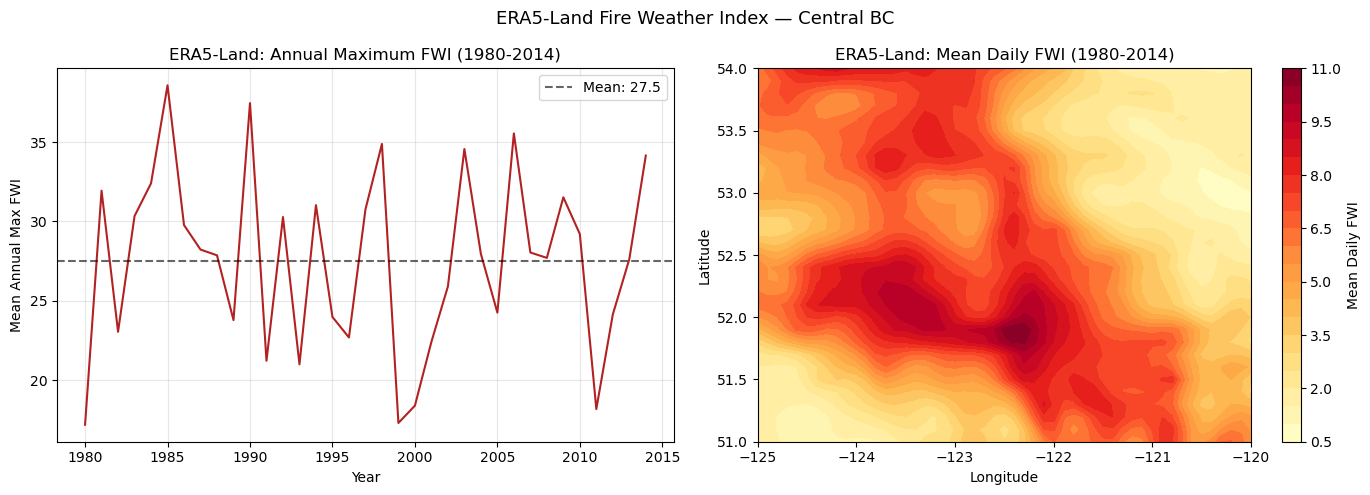

In [26]:
# Load ERA5-Land FWI
ds_era5 = xr.open_dataset(f'{FWI_DIR}/ERA5-Land_historical_fwi.nc')
print(ds_era5)

# Annual maximum FWI time series (spatial mean)
fwi_ann_max = ds_era5['fwi'].resample(time='YE').max()
ts = fwi_ann_max.mean(['lat','lon']).compute()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series
years = ts.time.dt.year.values
axes[0].plot(years, ts.values, color='firebrick', linewidth=1.5)
axes[0].axhline(float(ts.mean()), color='black', linestyle='--', alpha=0.6,
                label=f'Mean: {float(ts.mean()):.1f}')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Annual Max FWI')
axes[0].set_title('ERA5-Land: Annual Maximum FWI (1980-2014)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean spatial map
mean_fwi = ds_era5['fwi'].mean('time').compute()
im = axes[1].contourf(mean_fwi.lon, mean_fwi.lat, mean_fwi.values,
                      levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=axes[1], label='Mean Daily FWI')
axes[1].set_title('ERA5-Land: Mean Daily FWI (1980-2014)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('ERA5-Land Fire Weather Index — Central BC', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2. FWI Climate Change Signal — All Models and Scenarios

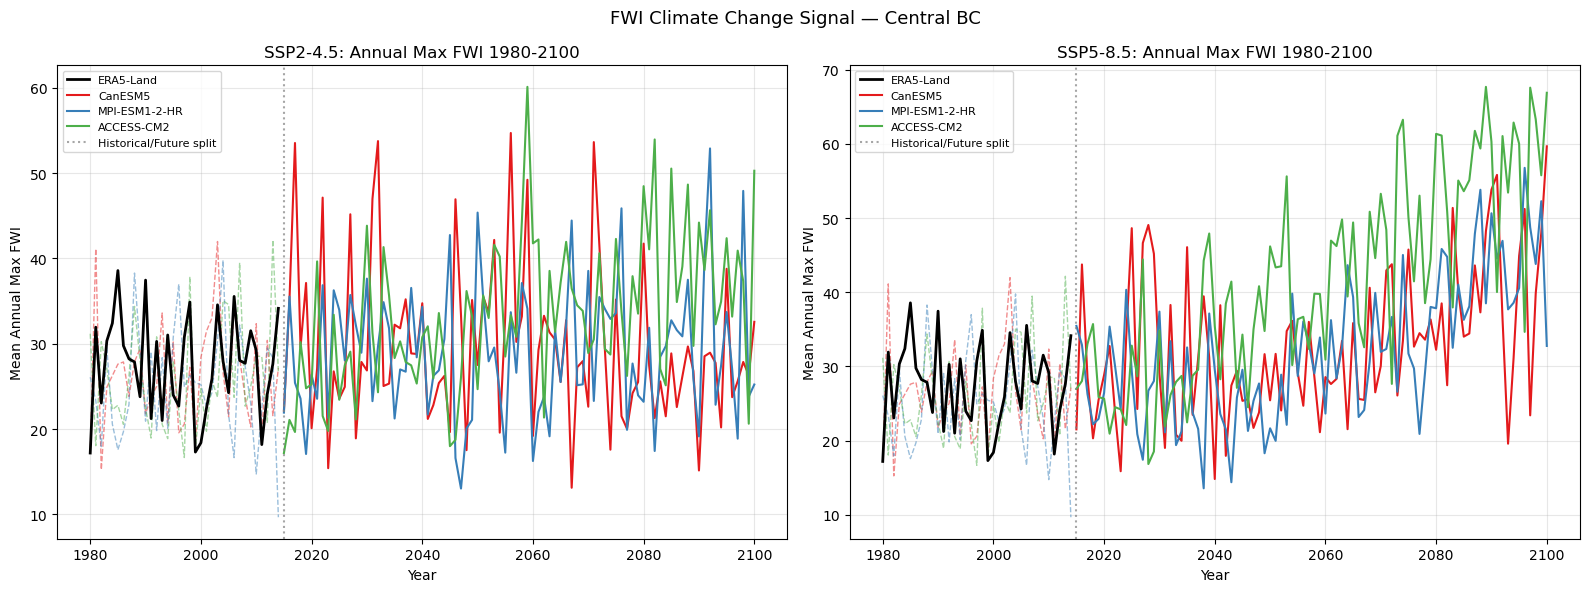

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'CanESM5': '#e41a1c', 'MPI-ESM1-2-HR': '#377eb8', 'ACCESS-CM2': '#4daf4a'}

# ERA5-Land baseline
era5_ts = ds_era5['fwi'].resample(time='YE').max().mean(['lat','lon']).compute()

for ax, scenario, title in [
    (axes[0], 'ssp245', 'SSP2-4.5'),
    (axes[1], 'ssp585', 'SSP5-8.5')
]:
    ax.plot(range(1980, 2015), era5_ts.values,
            color='black', linewidth=2, label='ERA5-Land', zorder=5)

    for model in MODELS:
        # Historical
        try:
            ds_h = xr.open_dataset(f'{FWI_DIR}/{model}_historical_fwi.nc')
            ts_h = ds_h['fwi'].resample(time='YE').max().mean(['lat','lon']).compute()
            ax.plot(ts_h.time.dt.year.values, ts_h.values,
                    color=colors[model], linewidth=1, alpha=0.5, linestyle='--')
        except FileNotFoundError:
            pass

        # Future
        try:
            ds_f = xr.open_dataset(f'{FWI_DIR}/{model}_{scenario}_fwi.nc')
            ts_f = ds_f['fwi'].resample(time='YE').max().mean(['lat','lon']).compute()
            ax.plot(ts_f.time.dt.year.values, ts_f.values,
                    color=colors[model], linewidth=1.5, label=model)
        except FileNotFoundError:
            pass

    ax.axvline(2015, color='grey', linestyle=':', alpha=0.7, label='Historical/Future split')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean Annual Max FWI')
    ax.set_title(f'{title}: Annual Max FWI 1980-2100')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('FWI Climate Change Signal — Central BC', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Annual Burn Probability — Historical

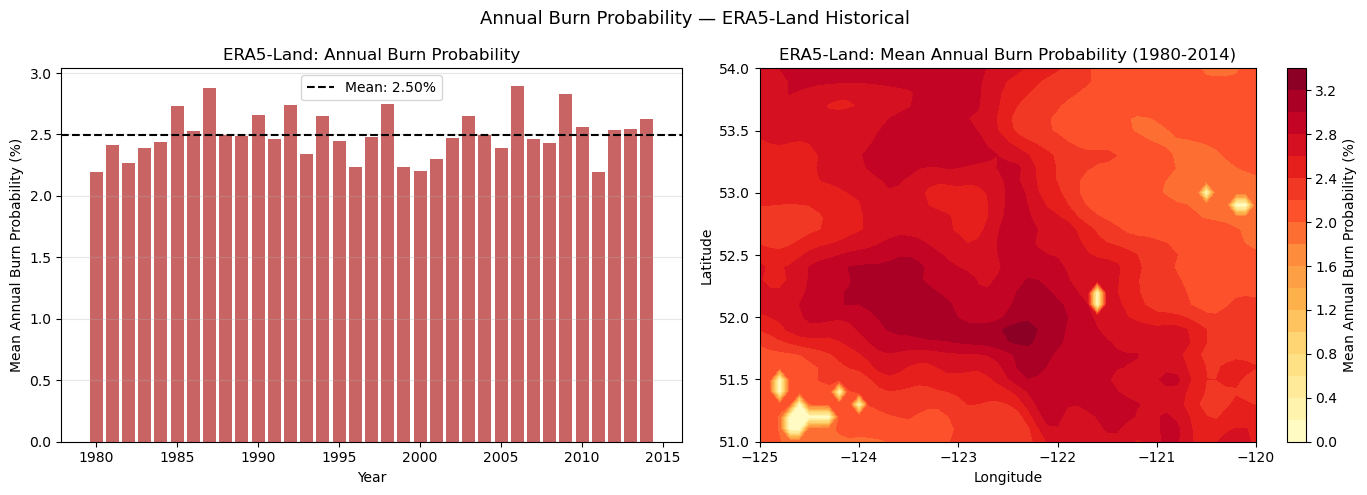

Mean annual burn probability: 2.497%
Max annual burn probability:  2.894%
Year of max: 2006


In [28]:
ds_abp = xr.open_dataset(f'{RES_DIR}/ERA5-Land_historical_annual_burn_probability.nc')
abp = ds_abp['annual_burn_probability']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spatial mean time series
ts_bp = abp.mean(['lat','lon'])
axes[0].bar(abp.year.values, ts_bp.values * 100, color='firebrick', alpha=0.7)
axes[0].axhline(float(ts_bp.mean()) * 100, color='black', linestyle='--',
                label=f'Mean: {float(ts_bp.mean())*100:.2f}%')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Annual Burn Probability (%)')
axes[0].set_title('ERA5-Land: Annual Burn Probability')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Mean spatial map
mean_abp = abp.mean('year')
im = axes[1].contourf(mean_abp.lon, mean_abp.lat, mean_abp.values * 100,
                      levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=axes[1], label='Mean Annual Burn Probability (%)')
axes[1].set_title('ERA5-Land: Mean Annual Burn Probability (1980-2014)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Annual Burn Probability — ERA5-Land Historical', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mean annual burn probability: {float(ts_bp.mean())*100:.3f}%')
print(f'Max annual burn probability:  {float(ts_bp.max())*100:.3f}%')
print(f'Year of max: {int(abp.year[int(ts_bp.argmax())].values)}')

---
## 4. Return Period Curves

In [29]:
# Load return period tables
rp_df  = pd.read_csv(f'{RES_DIR}/return_period_table.csv')
ens_df = pd.read_csv(f'{RES_DIR}/ensemble_return_period_table.csv')

print('Return period table:')
print(rp_df.to_string(index=False))
print('\nEnsemble return period table:')
print(ens_df.to_string(index=False))

Return period table:
                 dataset   rp_2yr   rp_5yr  rp_10yr  rp_20yr  rp_50yr  rp_100yr  rp_200yr  rp_500yr
    ERA5-Land_historical 0.024475 0.028949 0.034715 0.044120 0.066417  0.096303  0.145604  0.263120
      CanESM5_historical 0.024168 0.026552 0.027845 0.028907 0.030063  0.030793  0.031421  0.032120
          CanESM5_ssp245 0.028840 0.031811 0.032256 0.032397 0.032451  0.032462  0.032466  0.032468
          CanESM5_ssp585 0.025445 0.034973 0.047316 0.067537 0.115713  0.180588  0.288047  0.545443
MPI-ESM1-2-HR_historical 0.025211 0.029083 0.029662 0.029845 0.029915  0.029930  0.029935  0.029937
    MPI-ESM1-2-HR_ssp245 0.024683 0.035581 0.049657 0.072661 0.127315  0.200719  0.322027  0.611800
    MPI-ESM1-2-HR_ssp585 0.025180 0.037056 0.052444 0.077658 0.137738  0.218655  0.352706  0.673844
   ACCESS-CM2_historical 0.022838 0.031440 0.042592 0.060876 0.104471  0.163221  0.260598  0.494026
       ACCESS-CM2_ssp245 0.027652 0.030591 0.031032 0.031171 0.031225  0.031236

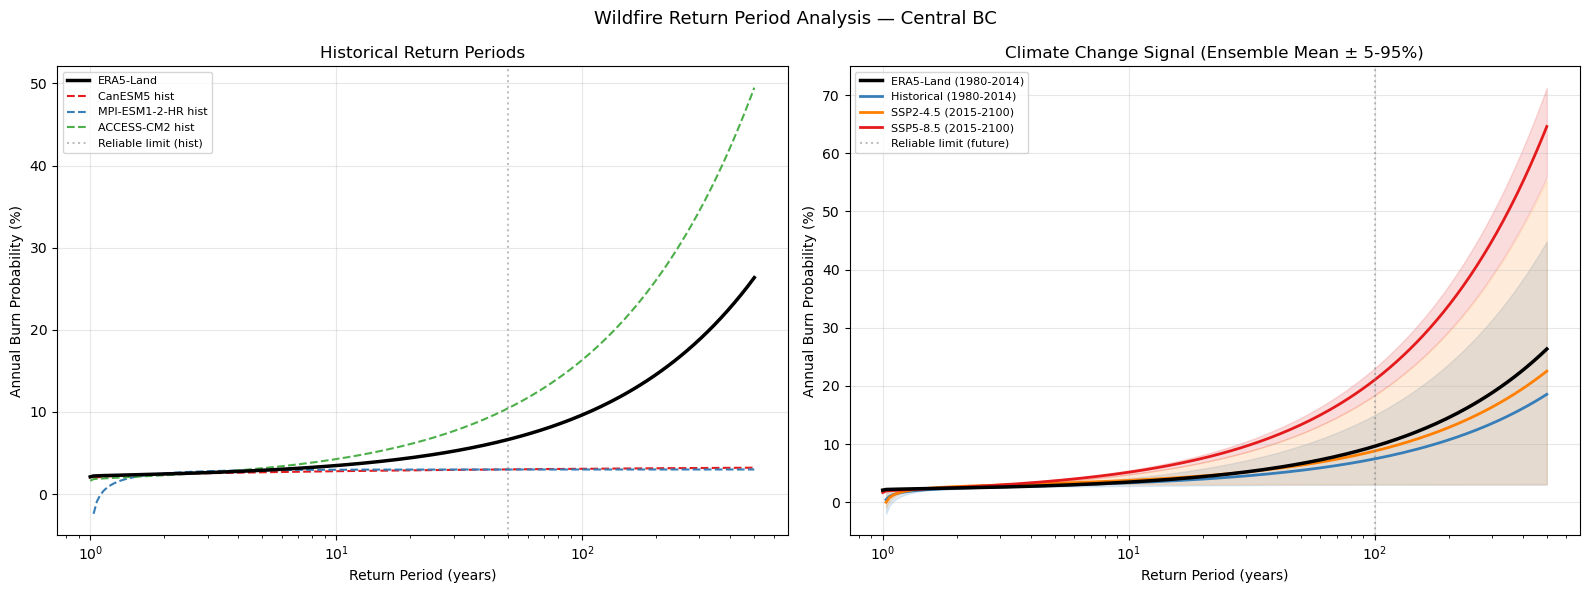

In [30]:
rp_list = [2, 5, 10, 20, 50, 100, 200, 500]
rp_range = np.logspace(0, 2.7, 200)
exceedance = 1 / rp_range

colors_scen = {
    'historical': '#377eb8',
    'ssp245':     '#ff7f00',
    'ssp585':     '#e41a1c'
}
labels_scen = {
    'historical': 'Historical (1980-2014)',
    'ssp245':     'SSP2-4.5 (2015-2100)',
    'ssp585':     'SSP5-8.5 (2015-2100)'
}

# Rebuild annual BP arrays from saved files
annual_bp_store = {}
for model in MODELS:
    for scenario in ['historical', 'ssp245', 'ssp585']:
        tag = f'{model}_{scenario}'
        try:
            ds = xr.open_dataset(f'{RES_DIR}/{tag}_annual_burn_probability.nc')
            annual_bp_store[tag] = np.nanmean(ds['annual_burn_probability'].values, axis=(1,2))
        except FileNotFoundError:
            pass

# ERA5-Land
ds_era5_abp = xr.open_dataset(f'{RES_DIR}/ERA5-Land_historical_annual_burn_probability.nc')
era5_mean = np.nanmean(ds_era5_abp['annual_burn_probability'].values, axis=(1,2))
gev_era5 = stats.genextreme.fit(era5_mean)
era5_curve = stats.genextreme.ppf(1 - exceedance, *gev_era5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-model historical comparison
ax = axes[0]
ax.plot(rp_range, era5_curve * 100, color='black', linewidth=2.5,
        label='ERA5-Land', zorder=5)
model_colors = {'CanESM5': '#e41a1c', 'MPI-ESM1-2-HR': '#377eb8', 'ACCESS-CM2': '#4daf4a'}
for model in MODELS:
    tag = f'{model}_historical'
    if tag not in annual_bp_store:
        continue
    p = stats.genextreme.fit(annual_bp_store[tag])
    curve = stats.genextreme.ppf(1 - exceedance, *p)
    ax.plot(rp_range, curve * 100, color=model_colors[model],
            linewidth=1.5, linestyle='--', label=f'{model} hist')
ax.axvline(50, color='grey', linestyle=':', alpha=0.5, label='Reliable limit (hist)')
ax.set_xscale('log')
ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Annual Burn Probability (%)')
ax.set_title('Historical Return Periods')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: ensemble climate change signal
ax = axes[1]
ax.plot(rp_range, era5_curve * 100, color='black', linewidth=2.5,
        label='ERA5-Land (1980-2014)', zorder=5)
for scenario in ['historical', 'ssp245', 'ssp585']:
    vals = [annual_bp_store.get(f'{m}_{scenario}') for m in MODELS]
    vals = [v for v in vals if v is not None]
    if not vals:
        continue
    curves = []
    for v in vals:
        p = stats.genextreme.fit(v)
        curves.append(stats.genextreme.ppf(1 - exceedance, *p))
    mean_c = np.mean(curves, axis=0)
    p5_c   = np.percentile(curves, 5, axis=0)
    p95_c  = np.percentile(curves, 95, axis=0)
    color  = colors_scen[scenario]
    ax.plot(rp_range, mean_c * 100, color=color, linewidth=2,
            label=labels_scen[scenario])
    ax.fill_between(rp_range, p5_c * 100, p95_c * 100, color=color, alpha=0.15)
ax.axvline(100, color='grey', linestyle=':', alpha=0.5, label='Reliable limit (future)')
ax.set_xscale('log')
ax.set_xlabel('Return Period (years)')
ax.set_ylabel('Annual Burn Probability (%)')
ax.set_title('Climate Change Signal (Ensemble Mean ± 5-95%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Wildfire Return Period Analysis — Central BC', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Climate Change Signal Summary Table

In [31]:
ens_pivot = ens_df.pivot(index='return_period', columns='scenario',
                          values='ensemble_mean') * 100
ens_pivot.columns.name = None
ens_pivot.index.name = 'Return Period (years)'

# Add ERA5-Land column
era5_col = ens_df[ens_df['scenario'] == 'historical'][['return_period', 'era5_land']]
era5_col = era5_col.set_index('return_period')['era5_land'] * 100
ens_pivot.insert(0, 'ERA5-Land', era5_col)

# Compute amplification factors
for col in ['ssp245', 'ssp585']:
    if col in ens_pivot.columns:
        ens_pivot[f'{col}_vs_hist'] = (ens_pivot[col] / ens_pivot['historical']).round(2)

print('Ensemble Mean Annual Burn Probability (%) by Return Period:')
print(ens_pivot.round(3).to_string())

Ensemble Mean Annual Burn Probability (%) by Return Period:
                       ERA5-Land  historical  ssp245  ssp585  ssp245_vs_hist  ssp585_vs_hist
Return Period (years)                                                                       
2                          2.447       2.407   2.706   2.561            1.12            1.06
5                          2.895       2.902   3.266   3.695            1.13            1.27
10                         3.472       3.337   3.765   5.165            1.13            1.55
20                         4.412       3.988   4.541   7.572            1.14            1.90
50                         6.642       5.482   6.366  13.310            1.16            2.43
100                        9.630       7.465   8.814  21.037            1.18            2.82
200                       14.560      10.732  12.858  33.839            1.20            3.15
500                       26.312      18.536  22.517  64.508            1.21            3.48


---
## 6. 30m Downscaled Burn Probability

The primary deliverables are GeoTIFFs in `data/outputs/results/`:
- `ERA5-Land_historical_burn_probability_30m.tif` — quantitative use
- `ACCESS-CM2_ssp585_2081-2100_burn_probability_30m.tif` — quantitative use
- `*_smoothed.tif` variants — presentation use

Open these in QGIS or ArcGIS for proper cartographic rendering. The cell below
aggregates to 1km resolution for a quick notebook overview — this is a display
convenience only, not an additional output.

In [32]:
# ── Toggle here ───────────────────────────────────────────────────────────────
USE_SMOOTHED = True  # False = raw tiled output, True = smoothed
# ─────────────────────────────────────────────────────────────────────────────

suffix = '_smoothed' if USE_SMOOTHED else ''
label  = 'smoothed' if USE_SMOOTHED else 'unsmoothed'

hist_30m = rxr.open_rasterio(
    f'{RES_DIR}/ERA5-Land_historical_burn_probability_30m{suffix}.tif'
).squeeze().values
fut_30m = rxr.open_rasterio(
    f'{RES_DIR}/ACCESS-CM2_ssp585_2081-2100_burn_probability_30m{suffix}.tif'
).squeeze().values

print(f'Loaded {label} outputs')
print(f'30m historical: mean={np.nanmean(hist_30m)*100:.3f}%, max={np.nanmax(hist_30m)*100:.3f}%')
print(f'30m future:     mean={np.nanmean(fut_30m)*100:.3f}%, max={np.nanmax(fut_30m)*100:.3f}%')

# Aggregate to 1km (block_size=33 pixels at 30m ≈ 990m) using nanmean
# This fills non-treed gaps naturally and produces a clean overview map
block = 33
nrows = hist_30m.shape[0] // block
ncols = hist_30m.shape[1] // block

def coarsen(arr, b):
    nr = arr.shape[0] // b
    nc = arr.shape[1] // b
    return np.nanmean(
        arr[:nr*b, :nc*b].reshape(nr, b, nc, b), axis=(1, 3)
    )

hist_1km = coarsen(hist_30m, block) * 100
fut_1km  = coarsen(fut_30m,  block) * 100

print(f'\n1km aggregated historical: mean={np.nanmean(hist_1km):.3f}%, shape={hist_1km.shape}')
print(f'1km aggregated future:     mean={np.nanmean(fut_1km):.3f}%, shape={fut_1km.shape}')

Loaded smoothed outputs
30m historical: mean=2.452%, max=3.143%
30m future:     mean=2.755%, max=3.508%

1km aggregated historical: mean=2.451%, shape=(160, 447)
1km aggregated future:     mean=2.754%, shape=(160, 447)


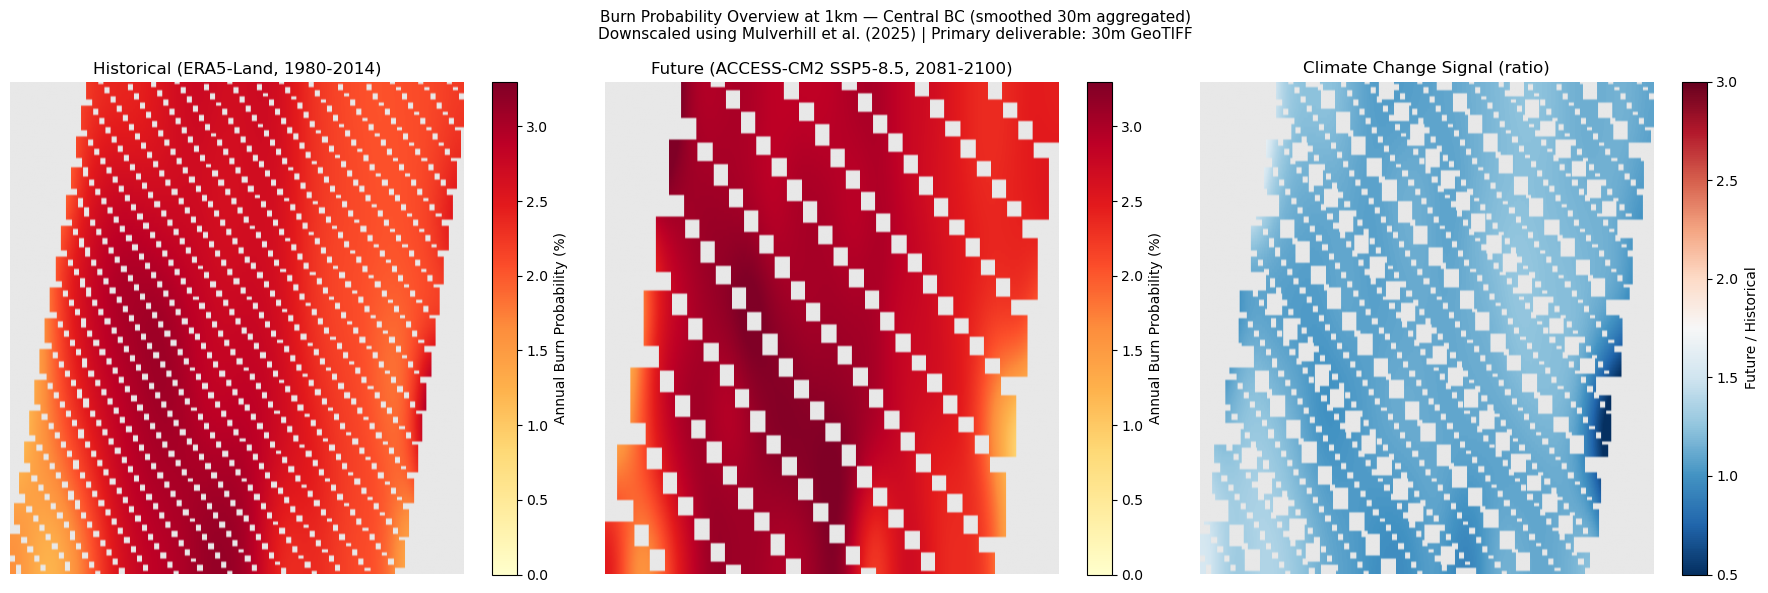

In [33]:
vmax = max(np.nanpercentile(hist_1km, 99), np.nanpercentile(fut_1km, 99))

cmap_bp    = plt.cm.YlOrRd.copy();   cmap_bp.set_bad('#e8e8e8')
cmap_ratio = plt.cm.RdBu_r.copy();  cmap_ratio.set_bad('#e8e8e8')

with np.errstate(invalid='ignore', divide='ignore'):
    ratio_1km = np.where(
        (hist_1km > 0.05) & ~np.isnan(hist_1km),
        fut_1km / hist_1km, np.nan
    )
ratio_1km = np.clip(ratio_1km, 0.5, 3.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(hist_1km, cmap=cmap_bp, vmin=0, vmax=vmax, aspect='auto')
plt.colorbar(im0, ax=axes[0], label='Annual Burn Probability (%)')
axes[0].set_title('Historical (ERA5-Land, 1980-2014)')
axes[0].axis('off')

im1 = axes[1].imshow(fut_1km, cmap=cmap_bp, vmin=0, vmax=vmax, aspect='auto')
plt.colorbar(im1, ax=axes[1], label='Annual Burn Probability (%)')
axes[1].set_title('Future (ACCESS-CM2 SSP5-8.5, 2081-2100)')
axes[1].axis('off')

im2 = axes[2].imshow(ratio_1km, cmap=cmap_ratio, vmin=0.5, vmax=3.0, aspect='auto')
plt.colorbar(im2, ax=axes[2], label='Future / Historical')
axes[2].set_title('Climate Change Signal (ratio)')
axes[2].axis('off')

plt.suptitle(
    f'Burn Probability Overview at 1km — Central BC ({label} 30m aggregated)\n'
    'Downscaled using Mulverhill et al. (2025) | Primary deliverable: 30m GeoTIFF',
    fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Burn Probability Distribution at 30m

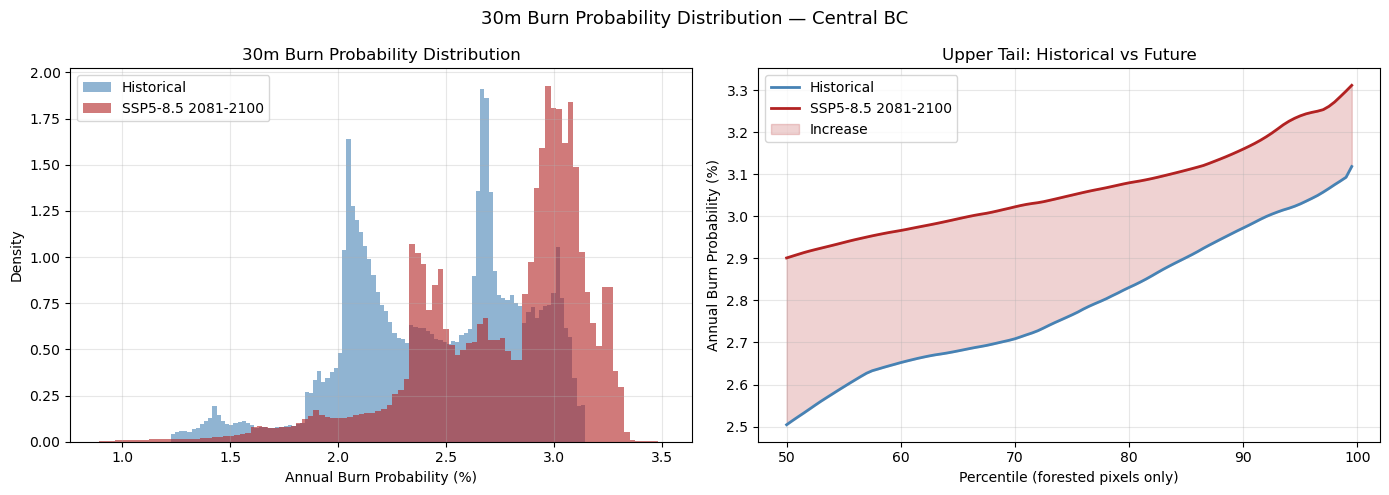

Historical p90: 2.972%
Future    p90: 3.160%
Historical p99: 3.093%
Future    p99: 3.297%


In [34]:
hist_flat = hist_30m.flatten()
fut_flat  = fut_30m.flatten()
hist_flat = hist_flat[~np.isnan(hist_flat) & (hist_flat > 0)]
fut_flat  = fut_flat[~np.isnan(fut_flat)  & (fut_flat  > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(hist_flat * 100, bins=100, alpha=0.6, color='steelblue',
             label='Historical', density=True)
axes[0].hist(fut_flat * 100,  bins=100, alpha=0.6, color='firebrick',
             label='SSP5-8.5 2081-2100', density=True)
axes[0].set_xlabel('Annual Burn Probability (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('30m Burn Probability Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Percentile comparison
pcts = np.arange(50, 100, 0.5)
h_pct = np.percentile(hist_flat * 100, pcts)
f_pct = np.percentile(fut_flat  * 100, pcts)
axes[1].plot(pcts, h_pct, color='steelblue', linewidth=2, label='Historical')
axes[1].plot(pcts, f_pct, color='firebrick', linewidth=2, label='SSP5-8.5 2081-2100')
axes[1].fill_between(pcts, h_pct, f_pct,
                     where=f_pct > h_pct, alpha=0.2, color='firebrick',
                     label='Increase')
axes[1].set_xlabel('Percentile (forested pixels only)')
axes[1].set_ylabel('Annual Burn Probability (%)')
axes[1].set_title('Upper Tail: Historical vs Future')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('30m Burn Probability Distribution — Central BC', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Historical p90: {np.percentile(hist_flat*100, 90):.3f}%')
print(f'Future    p90: {np.percentile(fut_flat*100,  90):.3f}%')
print(f'Historical p99: {np.percentile(hist_flat*100, 99):.3f}%')
print(f'Future    p99: {np.percentile(fut_flat*100,  99):.3f}%')

---
## 8. FWI Components — Drought Signal (DC and DMC)

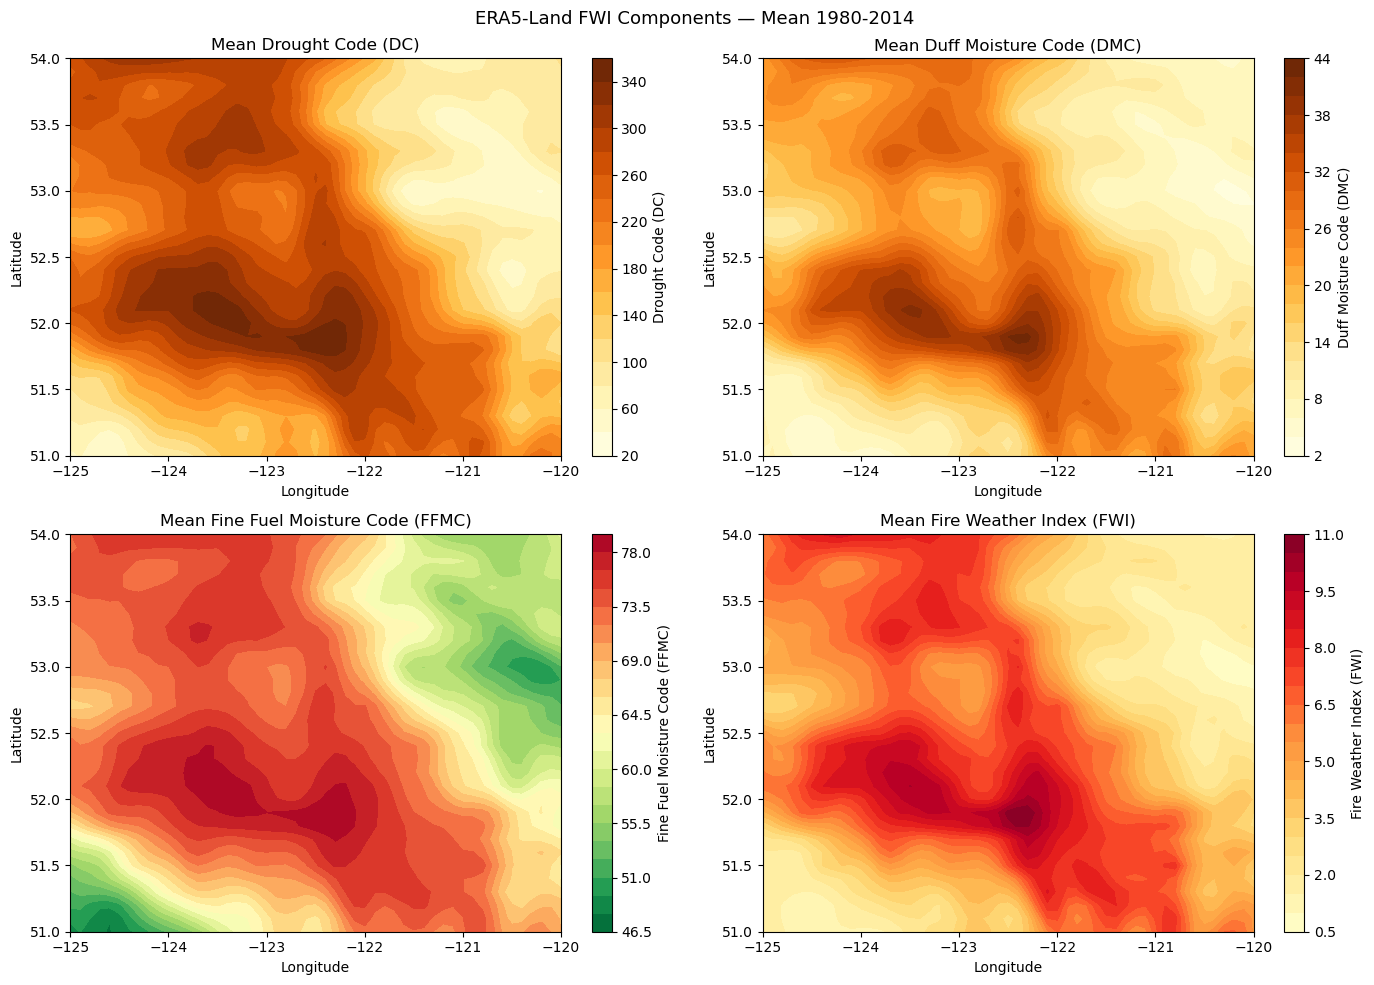

In [35]:
ds_comp = xr.open_dataset(f'{FWI_DIR}/ERA5-Land_historical_fwi_components.nc')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var, label, cmap in [
    (axes[0,0], 'dc',   'Drought Code (DC)',              'YlOrBr'),
    (axes[0,1], 'dmc',  'Duff Moisture Code (DMC)',       'YlOrBr'),
    (axes[1,0], 'ffmc', 'Fine Fuel Moisture Code (FFMC)', 'RdYlGn_r'),
    (axes[1,1], 'fwi',  'Fire Weather Index (FWI)',       'YlOrRd'),
]:
    mean_map = ds_comp[var].mean('time').compute()
    im = ax.contourf(mean_map.lon, mean_map.lat, mean_map.values,
                     levels=20, cmap=cmap)
    plt.colorbar(im, ax=ax, label=label)
    ax.set_title(f'Mean {label}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('ERA5-Land FWI Components — Mean 1980-2014', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Model Spread — FWI Historical Comparison

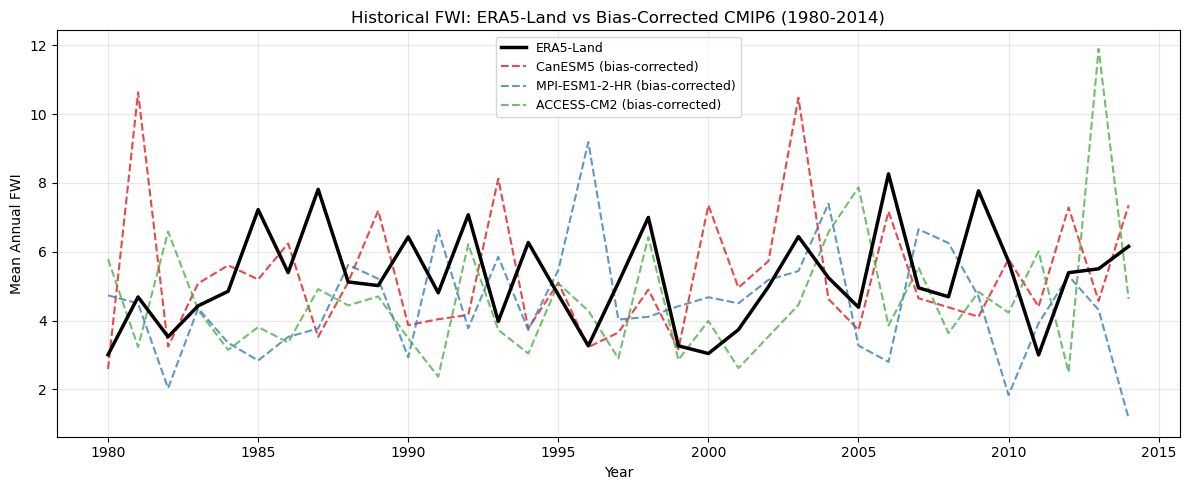

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))

# ERA5-Land
era5_ann = ds_era5['fwi'].resample(time='YE').mean().mean(['lat','lon']).compute()
ax.plot(era5_ann.time.dt.year.values, era5_ann.values,
        color='black', linewidth=2.5, label='ERA5-Land', zorder=5)

model_colors = {'CanESM5': '#e41a1c', 'MPI-ESM1-2-HR': '#377eb8', 'ACCESS-CM2': '#4daf4a'}
for model in MODELS:
    try:
        ds_h = xr.open_dataset(f'{FWI_DIR}/{model}_historical_fwi.nc')
        ts = ds_h['fwi'].resample(time='YE').mean().mean(['lat','lon']).compute()
        ax.plot(ts.time.dt.year.values, ts.values,
                color=model_colors[model], linewidth=1.5,
                linestyle='--', label=f'{model} (bias-corrected)', alpha=0.8)
    except FileNotFoundError:
        pass

ax.set_xlabel('Year')
ax.set_ylabel('Mean Annual FWI')
ax.set_title('Historical FWI: ERA5-Land vs Bias-Corrected CMIP6 (1980-2014)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

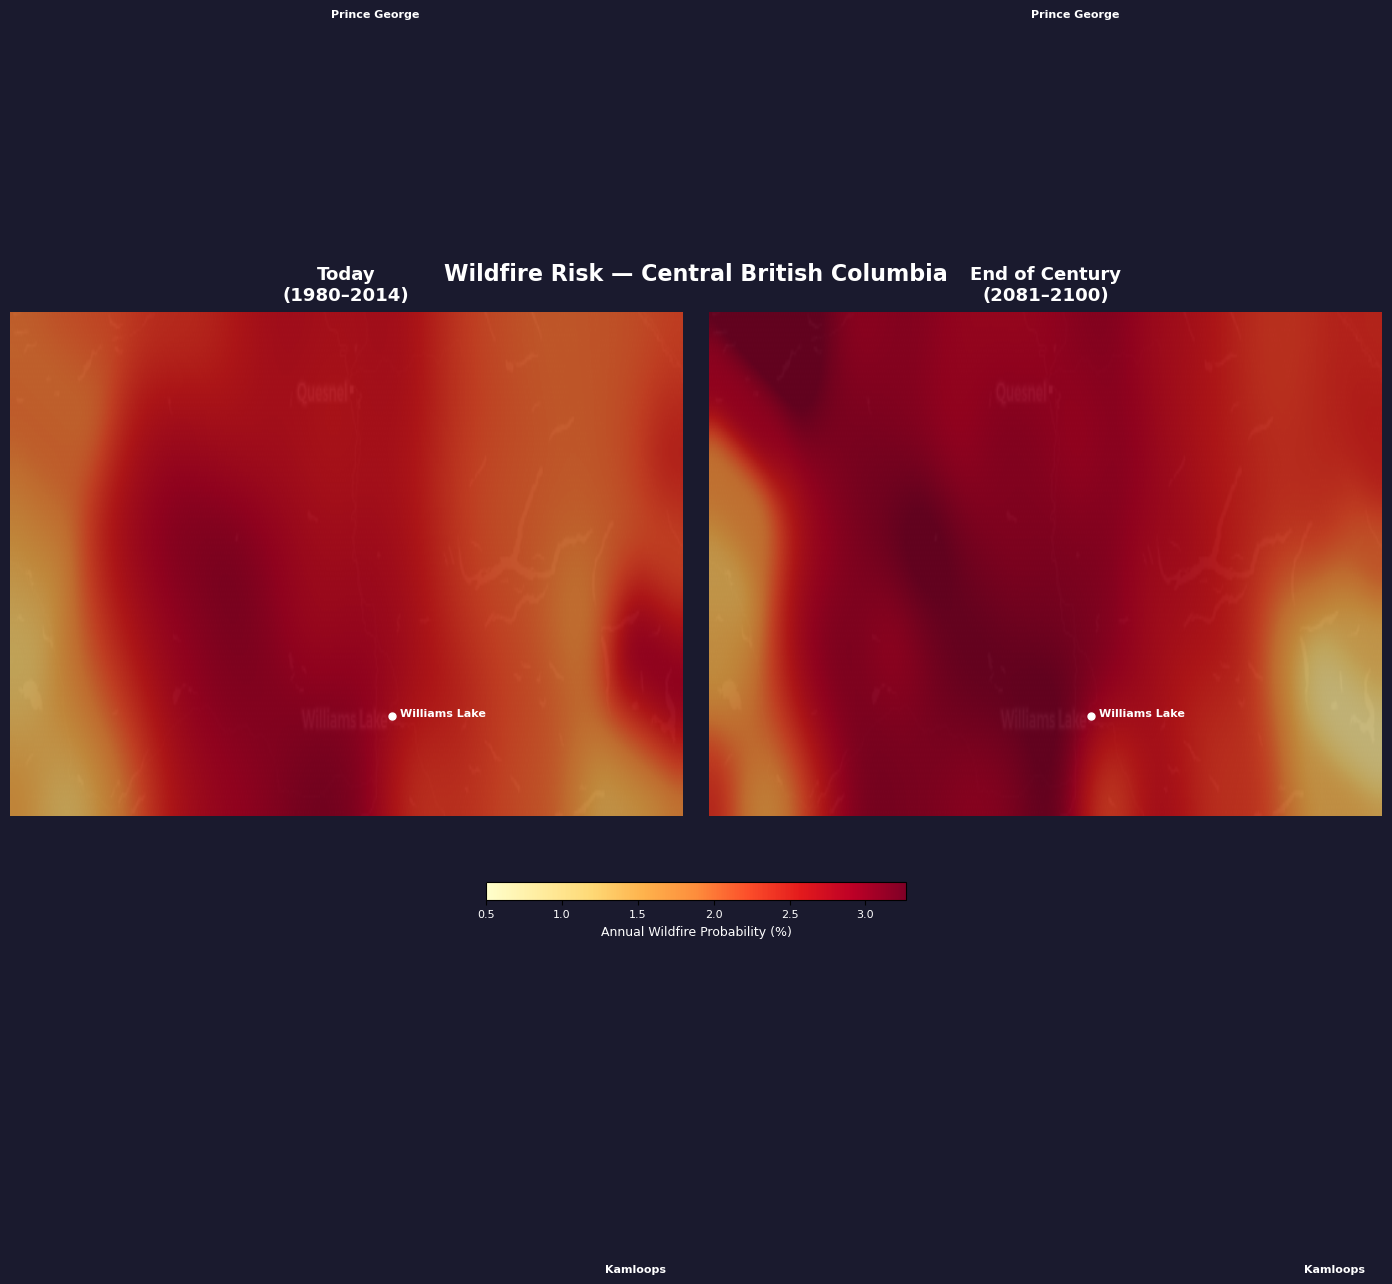

In [ ]:
import contextily as ctx
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pyproj import Transformer
import warnings
warnings.filterwarnings('ignore')

def coarsen(arr, b):
    nr, nc = arr.shape[0]//b, arr.shape[1]//b
    return np.nanmean(arr[:nr*b,:nc*b].reshape(nr,b,nc,b), axis=(1,3))

from scipy.ndimage import distance_transform_edt, gaussian_filter

def load_filled(path, block=33):
    arr = rxr.open_rasterio(path).squeeze().values
    # fill NaN with nearest neighbour then lightly smooth
    nan_mask = np.isnan(arr)
    _, idx = distance_transform_edt(nan_mask, return_indices=True)
    arr_filled = arr[idx[0], idx[1]]
    arr_filled = gaussian_filter(arr_filled.astype(np.float64), sigma=200)
    return coarsen(arr_filled, block) * 100

hist_1km = load_filled('data/outputs/results/ERA5-Land_historical_burn_probability_30m_smoothed.tif')
fut_1km  = load_filled('data/outputs/results/ACCESS-CM2_ssp585_2081-2100_burn_probability_30m_smoothed.tif')

# Get corner coordinates in EPSG:3857
t = Transformer.from_crs("EPSG:3978", "EPSG:3857", always_xy=True)
xs = hist.x.values[::block][:hist_1km.shape[1]]
ys = hist.y.values[::block][:hist_1km.shape[0]]
x0, _ = t.transform(xs.min(), ys.mean())
x1, _ = t.transform(xs.max(), ys.mean())
_, y0  = t.transform(xs.mean(), ys.min())
_, y1  = t.transform(xs.mean(), ys.max())

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color='#1a1a2e')
vmax = np.nanpercentile(fut_1km, 97)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#1a1a2e')

for ax, arr, title in zip(axes, [hist_1km, fut_1km],
                           ['Today\n(1980–2014)', 'End of Century\n(2081–2100)']):
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.DarkMatter,
                    zoom=7, attribution=False)
    ax.imshow(arr, extent=[x0,x1,y0,y1], origin='upper',
              cmap=cmap, vmin=0.5, vmax=vmax, alpha=0.55, zorder=2, aspect='auto')
    tw = Transformer.from_crs("EPSG:4326","EPSG:3857",always_xy=True)
    for name,(lon,lat) in {'Williams Lake':(-122.14,52.14),'Quesnel':(-122.49,52.98)}.items():
        x3,y3 = tw.transform(lon,lat)
        ax.plot(x3,y3,'o',color='white',markersize=5,zorder=5)
        ax.text(x3+8000,y3,name,color='white',fontsize=8,fontweight='bold',zorder=5)
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=8)
    ax.set_axis_off()

cbar_ax = fig.add_axes([0.35,0.06,0.30,0.025])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0.5,vmax=vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label('Annual Wildfire Probability (%)', color='white', fontsize=9)
plt.setp(cb.ax.xaxis.get_ticklabels(), color='white', fontsize=8)
fig.suptitle('Wildfire Risk — Central British Columbia',
             color='white', fontsize=16, fontweight='bold', y=0.97)
plt.subplots_adjust(left=0.01,right=0.99,top=0.90,bottom=0.18,wspace=0.04)
plt.savefig('data/outputs/figures/wildfire_risk.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()